In [1]:
# imports
from datasets import load_from_disk, load_dataset
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
from collections import Counter
import pandas as pd
import os
import re
import numpy as np
import gzip
import json

In [19]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 9,  # Match acmart sigconf default
})

In [3]:
language = 'Java'

ds = load_dataset(
    "AISE-TUDelft/the-heap",
    f"{language}",
    split="train",
    num_proc=12
)

print(len(ds))

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/67 [00:00<?, ?it/s]

5168193


In [4]:
# Load the annotation file, optionally gzipped
annotations = []
with gzip.open("../../../data/Java/satd_count_spans_annotations.jsonl.gz", "r") as f:
    for line in f:
        annotations.append(json.loads(line))

# Check length matches
assert len(ds) == len(annotations), "Length mismatch!"

def add_annotations(batch, indices):
    return {
        "satd_spans": [annotations[i]["satd_spans"] for i in indices],
        "satd_count": [annotations[i]["satd_count"] for i in indices],
    }

ds_all = ds.map(add_annotations, with_indices=True, batched=True, desc="Adding SATD spans and counts")

In [5]:
# load the non_satd file ids from json
with open("../../satd_annotate/investigation/non_satd_file_ids.json", "r") as f:
    non_satd_file_ids = json.load(f)

In [6]:
ds_non_satd = ds_all.filter(
    lambda example: example["id"] in non_satd_file_ids,
    desc="Filtering non-SATD files"
)

In [7]:
non_satd_counts = ds_non_satd["satd_count"]
print(sum(non_satd_counts), len(non_satd_counts))

215879 52


In [ ]:
NON_SATD_COMMENTS = [
    "Regression assertion (captures the current behavior of the code)",
    "the probability of lineage i being in state j is p[i*nr_states +j]",
    "public static final String XXXbid",
]

for comment in NON_SATD_COMMENTS:
    ds_non_satd_part = ds_non_satd.filter(
        lambda example: comment in example["content"],
        desc=f"Filtering files with comment containing: {comment}"
    )
    non_satd_counts_part = ds_non_satd_part["satd_count"]
    print(f"Count for '{comment}': {sum(non_satd_counts_part)} in {len(non_satd_counts_part)} files")


Count for 'Regression assertion (captures the current behavior of the code)': 210704 in 17 files
Count for 'the probability of lineage i being in state j is p[i*nr_states +j]': 4823 in 34 files
Count for 'public static final String XXXbid': 352 in 1 files
Count for 'leave it to the interceptor': 0 in 0 files


In [6]:
# Now filter directly using index
ds_filtered = ds_all.filter(
    lambda example: example["id"] not in non_satd_file_ids,
    desc="Filtering SATD files"
)

1. How much SATD is in the dataset?
2. How many files contain SATD?
3. Histogram of SATD count per file, average?
4. Counts of words in SATD comments


~SATD comments as a percentage of all comments\
~metrics per project/repository

In [7]:
# Ensure the directory exists
output_dir = "../../../data/presence/presence_all"
os.makedirs(output_dir, exist_ok=True)

In [9]:
total_entries = len(ds_all)
satd_counts = ds_filtered["satd_count"]
loc_counts = ds_all["total_lines"]

average_satd = sum(satd_counts) / total_entries
median_satd = sorted(satd_counts)[total_entries // 2] if satd_counts else 0
max_satd = max(satd_counts)

# Calculate the percentage of files with at least one SATD
files_with_satd = sum(1 for count in satd_counts if count > 0)
percentage_with_satd = (files_with_satd / total_entries) * 100
satd_per_kloc = sum(satd_counts) / (sum(loc_counts) / 1000) if sum(loc_counts) > 0 else 0

# Print the results
print(f"Total number of SATD comments: {sum(satd_counts)}")
print(f"Average SATD count per file: {average_satd:.2f}")
print(f"Median SATD count per file: {median_satd}")
print(f"Maximum SATD count in a single file: {max_satd}")
print(f"Percentage of files with at least one SATD: {percentage_with_satd:.2f}%")
print(f"SATD comments per KLOC: {satd_per_kloc:.2f}")

Total number of SATD comments: 914347
Average SATD count per file: 0.18
Median SATD count per file: 0
Maximum SATD count in a single file: 2230
Percentage of files with at least one SATD: 8.34%
SATD comments per KLOC: 1.26


In [10]:
files_with_satd

431145

In [11]:
sorted_satd_counts = sorted(satd_counts, reverse=True)
print(f"Top 10 files with the most SATD comments: {sorted_satd_counts[2:30]}")

Top 10 files with the most SATD comments: [325, 325, 323, 322, 265, 229, 228, 197, 177, 173, 162, 159, 156, 155, 146, 145, 136, 133, 132, 131, 131, 131, 128, 124, 124, 124, 121, 117]


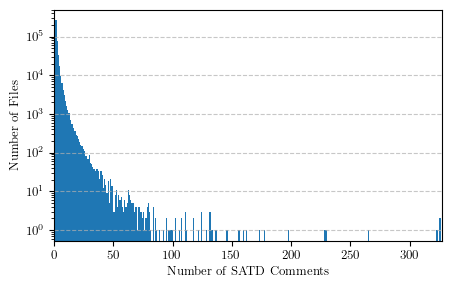

In [21]:
# Plot the histogram
plt.figure(figsize=(5, 3))
plt.hist(satd_counts, bins=range(1, max(sorted_satd_counts[2:]) + 2), log=True)
plt.xlabel('Number of SATD Comments')
plt.ylabel('Number of Files')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, max(sorted_satd_counts[2:]) + 2)
# save plt as pdf
plt.savefig(os.path.join(output_dir, "satd_histogram.pdf"), format='pdf', bbox_inches='tight')